# Joins and Set Operations

Up until now, we have queried data from a single table. But the true power of a Relational Database is right there in the name: **Relationships**. 

Real-world data is split across multiple tables to keep things organized and prevent duplication (Normalization). To do any meaningful analysis, we have to stitch those tables back together. We do this using **JOINS** (to combine columns horizontally) and **SET OPERATIONS** (to combine rows vertically).

Let's set up our Python environment with some intentionally mismatched data to see how different joins behave.

In [1]:
import sqlite3
import pandas as pd

# 1. Connect to an in-memory database
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 2. Create Customers and Orders tables
cursor.executescript("""
CREATE TABLE Customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT
);

CREATE TABLE Orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    product TEXT
);

-- Insert 3 Customers (Charlie hasn't bought anything)
INSERT INTO Customers (customer_id, name) VALUES 
(101, 'Alice'), 
(102, 'Bob'), 
(103, 'Charlie'); 

-- Insert 3 Orders (Customer 104 doesn't exist in our Customers table! Maybe a guest checkout)
INSERT INTO Orders (order_id, customer_id, product) VALUES 
(1, 101, 'Laptop'),
(2, 102, 'Mouse'),
(3, 104, 'Keyboard'); 
""")

print("✅ Database ready! We have some matching and non-matching data.")

✅ Database ready! We have some matching and non-matching data.


## 0.Visualizations of all Join Types

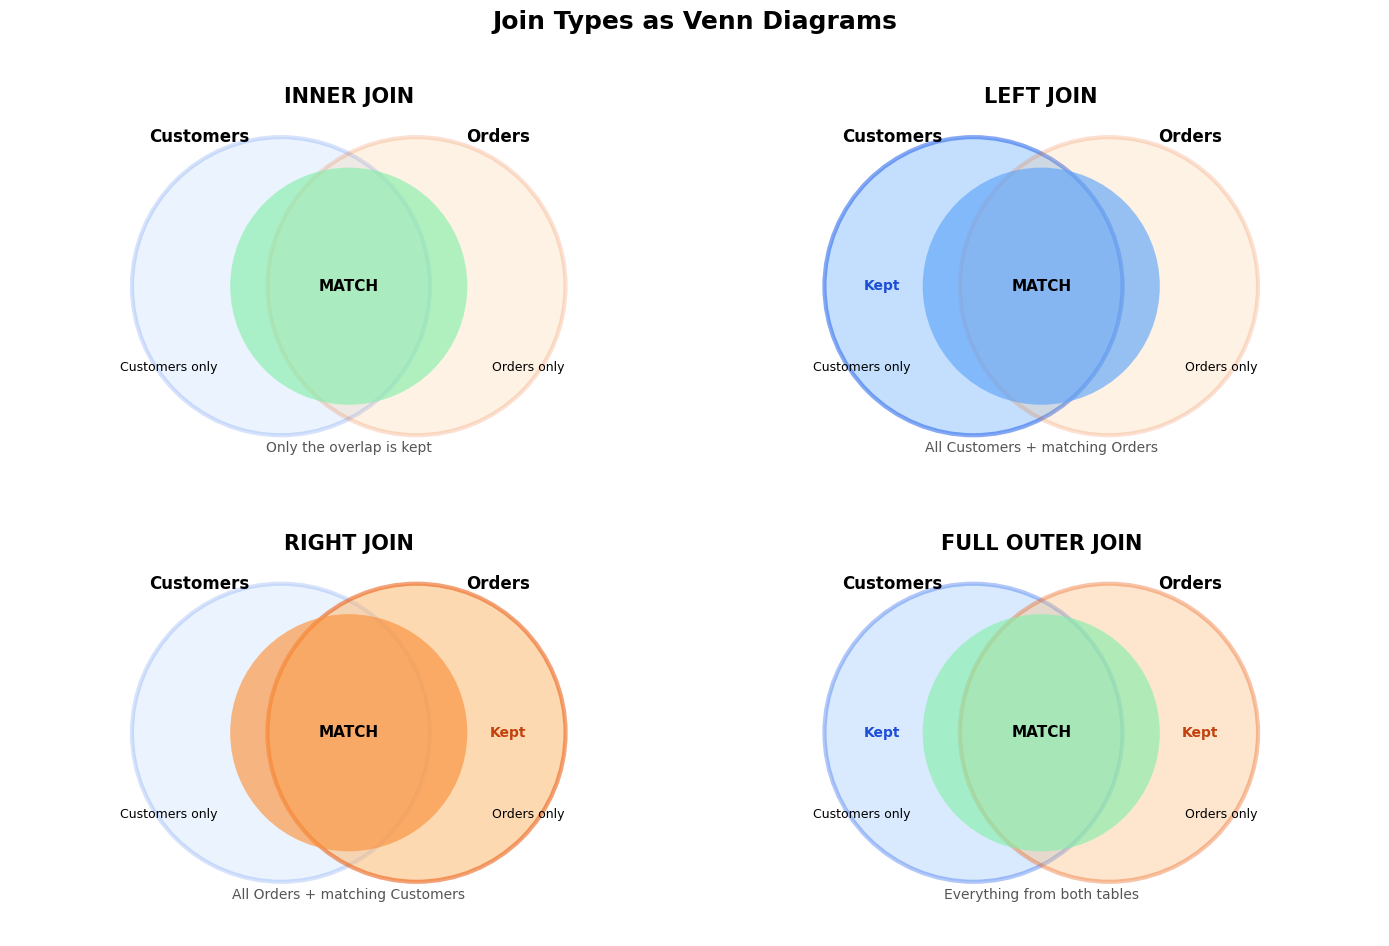

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Show each join type as its own Venn diagram.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

join_panels = [
    {
        'title': 'INNER JOIN',
        'subtitle': 'Only the overlap is kept',
        'left_alpha': 0.18,
        'right_alpha': 0.18,
        'overlap_color': '#86efac',
        'keep_left': False,
        'keep_right': False,
        'keep_overlap': True,
    },
    {
        'title': 'LEFT JOIN',
        'subtitle': 'All Customers + matching Orders',
        'left_alpha': 0.55,
        'right_alpha': 0.18,
        'overlap_color': '#60a5fa',
        'keep_left': True,
        'keep_right': False,
        'keep_overlap': True,
    },
    {
        'title': 'RIGHT JOIN',
        'subtitle': 'All Orders + matching Customers',
        'left_alpha': 0.18,
        'right_alpha': 0.55,
        'overlap_color': '#fb923c',
        'keep_left': False,
        'keep_right': True,
        'keep_overlap': True,
    },
    {
        'title': 'FULL OUTER JOIN',
        'subtitle': 'Everything from both tables',
        'left_alpha': 0.35,
        'right_alpha': 0.35,
        'overlap_color': '#86efac',
        'keep_left': True,
        'keep_right': True,
        'keep_overlap': True,
    },
]

for ax, panel in zip(axes, join_panels):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.set_aspect('equal')
    ax.axis('off')

    # Base circles for the two tables.
    left_circle = Circle((4, 3), 2.2, facecolor='#93c5fd', edgecolor='#2563eb', alpha=panel['left_alpha'], linewidth=3)
    right_circle = Circle((6, 3), 2.2, facecolor='#fdba74', edgecolor='#ea580c', alpha=panel['right_alpha'], linewidth=3)
    ax.add_patch(left_circle)
    ax.add_patch(right_circle)

    # Highlight the overlap for joins that keep matching rows.
    if panel['keep_overlap']:
        overlap = Circle((5, 3), 1.75, facecolor=panel['overlap_color'], edgecolor='none', alpha=0.65)
        ax.add_patch(overlap)

    # Emphasize the preserved outer sides when relevant.
    if panel['keep_left'] and not panel['keep_right']:
        ax.text(2.65, 3.0, 'Kept', ha='center', va='center', fontsize=10, fontweight='bold', color='#1d4ed8')
    elif panel['keep_right'] and not panel['keep_left']:
        ax.text(7.35, 3.0, 'Kept', ha='center', va='center', fontsize=10, fontweight='bold', color='#c2410c')
    elif panel['keep_left'] and panel['keep_right']:
        ax.text(2.65, 3.0, 'Kept', ha='center', va='center', fontsize=10, fontweight='bold', color='#1d4ed8')
        ax.text(7.35, 3.0, 'Kept', ha='center', va='center', fontsize=10, fontweight='bold', color='#c2410c')

    # Labels for the two tables.
    ax.text(2.8, 5.2, 'Customers', ha='center', va='center', fontsize=12, fontweight='bold')
    ax.text(7.2, 5.2, 'Orders', ha='center', va='center', fontsize=12, fontweight='bold')

    # Region labels that explain the join behavior.
    ax.text(2.35, 1.8, 'Customers only', ha='center', va='center', fontsize=9)
    ax.text(5.0, 3.0, 'MATCH', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(7.65, 1.8, 'Orders only', ha='center', va='center', fontsize=9)

    ax.text(5, 5.7, panel['title'], ha='center', fontsize=15, fontweight='bold')
    ax.text(5, 0.55, panel['subtitle'], ha='center', fontsize=10, color='#555')

fig.suptitle('Join Types as Venn Diagrams', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 1. INNER JOIN (The Intersection)
An `INNER JOIN` is the most common join. Think of it like a strict matching process: a row is included only if there is a **perfect match in BOTH tables**.

If a customer has no orders, they are dropped. If an order has an unknown customer, it is dropped.

In [2]:
# Give me only the customers who have placed an order, AND their order details.
query_inner = """
SELECT Customers.name, Orders.product
FROM Customers
INNER JOIN Orders 
    ON Customers.customer_id = Orders.customer_id;
"""
print("--- INNER JOIN (Only Perfect Matches) ---")
display(pd.read_sql_query(query_inner, conn))

--- INNER JOIN (Only Perfect Matches) ---


,name,product
0,Alice,Laptop
1,Bob,Mouse


*(Notice that Charlie is missing because he has no orders, and the Keyboard is missing because customer 104 doesn't exist.)*

# 2. LEFT JOIN (The Foundation)
A `LEFT JOIN` grabs **EVERYTHING from the left table** (the one written first), and only the matching data from the right table. 

If there is no match on the right side, the database fills in the blanks with `NULL` (empty) values. This is incredibly useful for finding missing data (e.g., "Show me all customers who have *never* bought anything").

In [3]:
# Give me ALL customers, and their orders if they have any.
query_left = """
SELECT Customers.name, Orders.product
FROM Customers
LEFT JOIN Orders 
    ON Customers.customer_id = Orders.customer_id;
"""
print("--- LEFT JOIN (All Customers, Matching Orders) ---")
display(pd.read_sql_query(query_left, conn))

--- LEFT JOIN (All Customers, Matching Orders) ---


,name,product
0,Alice,Laptop
1,Bob,Mouse
2,Charlie,None


*(Notice Charlie is back! But his product is `None` (NULL) because he hasn't ordered anything.)*

# 3. RIGHT and FULL OUTER JOINS (And the Python Bridge)
* **`RIGHT JOIN`**: Grabs everything from the right table, and only matches from the left.
* **`FULL OUTER JOIN`**: Grabs absolutely everything from both tables. If things don't match, it puts `NULL`s everywhere.

**Important Data Science Note:** SQLite (the lightweight database we are using here) *does not fully support* RIGHT or FULL OUTER joins. However, since we are using Python, we can easily pull the raw tables into Pandas and do the join there using `pd.merge()`!

In [4]:
# Pull the raw tables into Pandas DataFrames
df_customers = pd.read_sql_query("SELECT * FROM Customers;", conn)
df_orders = pd.read_sql_query("SELECT * FROM Orders;", conn)

# Perform a FULL OUTER JOIN using Pandas
full_outer_join = pd.merge(df_customers, df_orders, on='customer_id', how='outer')

print("--- FULL OUTER JOIN (Using Pandas) ---")
display(full_outer_join)

--- FULL OUTER JOIN (Using Pandas) ---


,customer_id,name,order_id,product
0,101,Alice,1.0,Laptop
1,102,Bob,2.0,Mouse
2,103,Charlie,NaN,NaN
3,104,NaN,3.0,Keyboard


*(Now we see everyone: Charlie with a `NaN` product, AND the Keyboard with a `NaN` customer name!)*

# 4. Set Operations: UNION, INTERSECT, EXCEPT
While JOINS combine tables side-by-side (adding columns), **Set Operations** stack tables on top of each other (adding rows). To do this, both queries must output the exact same number of columns with matching data types.

Let's create two new tables to demonstrate: `US_Customers` and `EU_Customers`.

In [5]:
cursor.executescript("""
CREATE TABLE US_Customers (name TEXT);
CREATE TABLE EU_Customers (name TEXT);

INSERT INTO US_Customers VALUES ('Alice'), ('Bob'), ('Dave');
INSERT INTO EU_Customers VALUES ('Alice'), ('Eve'), ('Frank');
""")

# UNION: Stacks the two lists together and removes duplicates.
# (If you want to keep duplicates, use UNION ALL).
query_union = """
SELECT name FROM US_Customers
UNION
SELECT name FROM EU_Customers;
"""
print("\n--- UNION (Everyone, no duplicates) ---")
display(pd.read_sql_query(query_union, conn))

# INTERSECT: Only shows rows that exist in BOTH lists.
query_intersect = """
SELECT name FROM US_Customers
INTERSECT
SELECT name FROM EU_Customers;
"""
print("\n--- INTERSECT (Only people in BOTH regions) ---")
display(pd.read_sql_query(query_intersect, conn))

# Clean up
conn.close()


--- UNION (Everyone, no duplicates) ---


,name
0,Alice
1,Bob
2,Dave
3,Eve
4,Frank



--- INTERSECT (Only people in BOTH regions) ---


,name
0,Alice


## Real-World Use Case or Analogy:
Think of Joins like managing a **Wedding Guest List**:

* **Left Table (`Invites`)**: A list of everyone you invited to the wedding.
* **Right Table (`RSVPs`)**: A list of meal choices mailed back by guests.

* **INNER JOIN**: The caterer's list. You only want the people who were invited *AND* mailed back a meal choice. 
* **LEFT JOIN**: The host's checklist. You want the entire list of people you invited, showing their meal choice if they replied, or a blank (`NULL`) if they are ignoring your emails so you know who to call.
* **RIGHT JOIN**: The party crasher list. You look at every single RSVP meal card received, matching them to invited guests, but explicitly keeping the cards from people who *weren't* on the original invite list (Guest checked out as `104`).
* **UNION**: You take the list of invites from the Bride's family, take the list of invites from the Groom's family, and stack them into one giant Master Document (removing the duplicates if they invited the same mutual friend).

---